# Dados de treinamento — NHAMCS-ED 2021

Este notebook prepara e valida a base que será usada na comparação de modelos.
Ele não treina algoritmos e não repete a qualidade da fonte nem a EDA clínica
dos notebooks 00 e 01.

| Papel | Coluna | Definição |
|---|---|---|
| Feature | `clinical_text` | Texto em inglês com idade, sexo, motivos da visita, dor e sinais vitais disponíveis na triagem |
| Target | `target` | `normal`, `atencao` ou `urgente`, derivado de `IMMEDR` 1–5 |
| Partição | `split` | 70% treino, 15% validação e 15% teste |

Diagnósticos e desfechos posteriores à triagem não entram no artefato.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

for import_root in (PROJECT_ROOT, PROJECT_ROOT / "src"):
    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

from hospital_triage.data_preparation import (  # noqa: E402, RUF100
    DATASET_VERSION,
    EXPECTED_CLASS_COUNTS,
    EXPECTED_ELIGIBLE_ROWS,
    EXPECTED_UNIQUE_TEXTS,
    TARGET_ORDER,
    TRAINING_COLUMNS,
    prepare_training_data,
)
from ml_prep_kit import (  # noqa: E402, RUF100
    DataValidator,
    SQLiteDataFrameStore,
)

SOURCE_PATH = (
    PROJECT_ROOT / "data/raw/nhamcs/2021/ed2021-stata.dta"
)
DATABASE_PATH = PROJECT_ROOT / "data/processed/training_data.db"
TARGET_COLORS = ["#2ca02c", "#ffbf00", "#d62728"]

plt.style.use("ggplot")
pd.set_option("display.max_colwidth", 160)

/Users/cassiojr/FIAP/Tech Challenge 3/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Geração e proveniência

In [2]:
prepare_training_data(SOURCE_PATH, DATABASE_PATH)

store = SQLiteDataFrameStore(DATABASE_PATH)
validator = DataValidator()
data = store.load_dataframe("training_data")
metadata = store.load_dataframe("metadata").set_index("key")

display(metadata)
print(f"Artefato: {DATABASE_PATH.relative_to(PROJECT_ROOT)}")

,value
key,
dataset_version,nhamcs-ed-2021-training-v1
source_sha256,c1438773d451c78652bf371fc369da5281aa2c82eb5983cccc2646b66d218038
row_count,10495
class_counts,"{""atencao"": 5429, ""normal"": 3186, ""urgente"": 1880}"
split_counts,"{""test"": 1572, ""train"": 7350, ""validation"": 1573}"
split_strategy,StratifiedGroupKFold: 70/15/15 by text_hash
random_state,42
sklearn_version,1.9.0


Artefato: data/processed/training_data.db


## 2. Qualidade final e distribuição do target

O banco deve conter somente seis colunas, sem nulos e sem reamostragem das
classes. `record_id`, `text_hash` e `split` são campos de governança, não
features do modelo.

,dataset,rows,columns,memory_mb
0,training_data,10495,6,7.13


,column,dtype,nulls,unique_values
0,record_id,object,0,10495
1,clinical_text,object,0,10492
2,target,object,0,3
3,text_hash,object,0,10492
4,split,object,0,3
5,dataset_version,object,0,1


,dataset,duplicate_rows,duplicate_rate
0,training_data,0,0.0


,rows,rate
target,,
normal,3186,30.36%
atencao,5429,51.73%
urgente,1880,17.91%


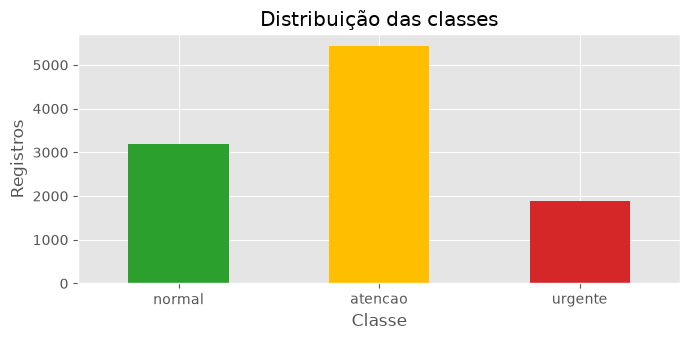

Razão entre maior e menor classe: 2.89x


In [3]:
summary = validator.summarize(data, "training_data")
schema = validator.describe_schema({"training_data": data})
duplicates = validator.duplicated_rows_by_table(
    {"training_data": data}
)
target_distribution = (
    data["target"]
    .value_counts()
    .reindex(TARGET_ORDER)
    .rename("rows")
    .to_frame()
)
target_distribution["rate"] = target_distribution["rows"] / len(data)

display(summary.style.format({"memory_mb": "{:.2f}"}))
display(schema[["column", "dtype", "nulls", "unique_values"]])
display(duplicates)
display(target_distribution.style.format({"rate": "{:.2%}"}))

target_distribution["rows"].plot.bar(
    color=TARGET_COLORS,
    figsize=(7, 3.5),
    title="Distribuição das classes",
    xlabel="Classe",
    ylabel="Registros",
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

imbalance_ratio = (
    target_distribution["rows"].max()
    / target_distribution["rows"].min()
)
print(f"Razão entre maior e menor classe: {imbalance_ratio:.2f}x")

## 3. Texto que será entregue ao modelo

In [4]:
text_summary = pd.DataFrame(
    {
        "characters": data["clinical_text"].str.len(),
        "tokens": data["clinical_text"].str.split().str.len(),
    }
).describe(percentiles=[0.05, 0.50, 0.95])

coverage = pd.Series(
    {
        "reason_for_visit": data["clinical_text"].str.contains(
            "Reasons for visit:",
            regex=False,
        ).mean(),
        "triage_observations": data["clinical_text"].str.contains(
            "Triage observations:",
            regex=False,
        ).mean(),
    },
    name="coverage",
).to_frame()

examples = (
    data.sort_values("record_id")
    .groupby("target", sort=False)
    .head(1)[["clinical_text", "target", "split"]]
)

display(text_summary.round(1))
display(coverage.style.format("{:.2%}"))
display(examples.reset_index(drop=True))

,characters,tokens
count,10495.0,10495.0
mean,252.1,36.6
std,43.9,5.9
min,50.0,9.0
5%,192.0,28.0
50%,244.0,36.0
95%,331.0,47.0
max,405.0,58.0


,coverage
reason_for_visit,99.97%
triage_observations,99.43%


,clinical_text,target,split
0,"Age: 22 years. Sex: Male. Reasons for visit: Throat soreness; Abdominal pain, cramps, spasms, NOS; Nausea; Ingestion, inhalation, or exposure to.... Triage ...",atencao,train
1,Age: 74 years. Sex: Male. Reasons for visit: Weakness (neurologic). Triage observations: heart rate 122 bpm; respiratory rate 22/min; blood pressure 122/56 ...,urgente,train
2,"Age: 46 years. Sex: Male. Reasons for visit: Injury, other and unspecified, of han...; Injury, other and unspecified, of wrist; Injury, other and unspecifie...",normal,train


O texto é templado a partir de campos estruturados. Valores ausentes são
omitidos, sem imputação e sem afirmar que uma medição é “normal”.

## 4. Splits e prevenção de vazamento

target,normal,atencao,urgente
split,,,
train,2232,3802,1316
validation,477,814,282
test,477,813,282


target,normal,atencao,urgente
split,,,
train,30.37%,51.73%,17.90%
validation,30.32%,51.75%,17.93%
test,30.34%,51.72%,17.94%


,observed
unique_texts,10492.000000
repeated_text_groups,3.000000
conflicting_targets,0.000000
groups_crossing_splits,0.000000
maximum_class_drift_pp,0.033092


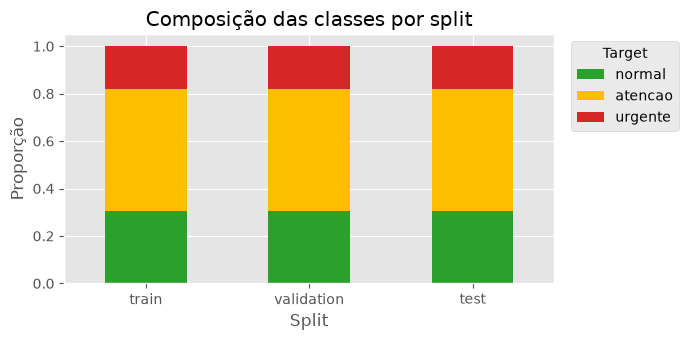

In [5]:
split_counts = pd.crosstab(data["split"], data["target"]).reindex(
    index=["train", "validation", "test"],
    columns=TARGET_ORDER,
    fill_value=0,
)
split_sizes = split_counts.sum(axis=1)
split_rates = split_counts.div(split_sizes, axis=0)
global_rates = data["target"].value_counts(normalize=True)
maximum_class_drift = (
    split_rates.sub(global_rates, axis=1).abs().to_numpy().max() * 100
)

hash_groups = data.groupby("text_hash").agg(
    rows=("record_id", "size"),
    targets=("target", "nunique"),
    splits=("split", "nunique"),
)
split_audit = pd.Series(
    {
        "unique_texts": data["text_hash"].nunique(),
        "repeated_text_groups": int(hash_groups["rows"].gt(1).sum()),
        "conflicting_targets": int(hash_groups["targets"].gt(1).sum()),
        "groups_crossing_splits": int(hash_groups["splits"].gt(1).sum()),
        "maximum_class_drift_pp": maximum_class_drift,
    },
    name="observed",
).to_frame()

display(split_counts)
display(split_rates.style.format("{:.2%}"))
display(split_audit)

split_rates.plot.bar(
    stacked=True,
    color=TARGET_COLORS,
    figsize=(7, 3.5),
    title="Composição das classes por split",
    xlabel="Split",
    ylabel="Proporção",
)
plt.xticks(rotation=0)
plt.legend(title="Target", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 5. Decisão de prontidão

In [6]:
checks = {
    "schema correto": tuple(data.columns) == TRAINING_COLUMNS,
    "volume esperado": len(data) == EXPECTED_ELIGIBLE_ROWS,
    "sem nulos": not data.isna().any().any(),
    "record_id único": data["record_id"].is_unique,
    "classes esperadas": (
        data["target"].value_counts().to_dict()
        == EXPECTED_CLASS_COUNTS
    ),
    "textos únicos esperados": (
        data["text_hash"].nunique() == EXPECTED_UNIQUE_TEXTS
    ),
    "sem conflito de target": not hash_groups["targets"].gt(1).any(),
    "sem vazamento entre splits": not hash_groups["splits"].gt(1).any(),
    "classes presentes nos splits": split_counts.gt(0).all().all(),
    "drift máximo até 0,5 p.p.": maximum_class_drift <= 0.5,
    "versão fixa": set(data["dataset_version"]) == {DATASET_VERSION},
}
gates = pd.Series(checks, name="passed").to_frame()
gates["status"] = gates["passed"].map({True: "PASS", False: "FAIL"})
display(gates[["status"]])

assert all(checks.values()), "A base de treinamento falhou nos gates."
print(
    f"Base aprovada: {len(data):,} registros; "
    f"{split_sizes['train']:,} treino, "
    f"{split_sizes['validation']:,} validação e "
    f"{split_sizes['test']:,} teste."
)

,status
schema correto,PASS
volume esperado,PASS
sem nulos,PASS
record_id único,PASS
classes esperadas,PASS
textos únicos esperados,PASS
sem conflito de target,PASS
sem vazamento entre splits,PASS
classes presentes nos splits,PASS
"drift máximo até 0,5 p.p.",PASS


Base aprovada: 10,495 registros; 7,350 treino, 1,573 validação e 1,572 teste.


## Conclusão

A base está pronta para a comparação de modelos. O próximo notebook deve
ajustar vetorizadores apenas no `train`, escolher o modelo no `validation` e
preservar o `test` até a decisão final.

Limitações que permanecem:

- o texto é derivado e não representa um laudo narrativo livre;
- o target é a prioridade registrada na triagem, não diagnóstico ou desfecho;
- os dados e a futura API desta versão trabalham em inglês;
- o split mede generalização entre visitas, não para hospitais inéditos.